In [2]:
import pandas as pd

df = pd.read_csv("osdebt.csv")
df

,Year,Month,Total
0,1993,Jan,959041
1,1993,Feb,977521
2,1993,Mar,1015620
3,1993,Apr,947491
4,1993,May,966498
...,...,...,...
391,2025,August,17421397
392,2025,September,17566015
393,2025,October,17560000
394,2025,November,17833185


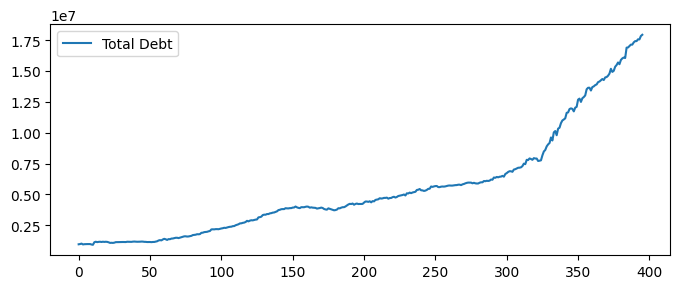

In [3]:
import matplotlib.pyplot as plt

y = df["Total"].astype(float)

fig, ax = plt.subplots(figsize=(8, 3))
y.plot(ax=ax, label='Total Debt')
ax.legend(loc='upper left');

In [4]:
y_diff = y.diff().dropna().reset_index(drop=True)
y_diff

0       18480.0
1       38099.0
2      -68129.0
3       19007.0
4        7554.0
         ...   
390         0.0
391    144618.0
392     -6015.0
393    273185.0
394    101928.0
Name: Total, Length: 395, dtype: float64

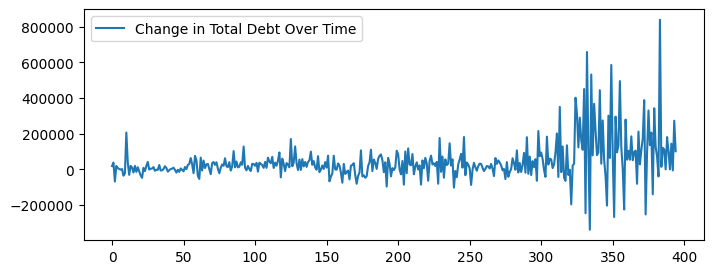

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
y_diff.plot(ax=ax, label='Change in Total Debt Over Time')
ax.legend(loc='upper left');

In [6]:
from skforecast.preprocessing.preprocessing import RollingFeatures
from sklearn.ensemble import RandomForestRegressor
from skforecast.recursive import ForecasterRecursive

target_col = 'Total'
forecaster = ForecasterRecursive(
                estimator=RandomForestRegressor(random_state=42, n_estimators=100, criterion='squared_error', n_jobs=-1),
                window_features=RollingFeatures(stats=['mean'], window_sizes=24),
                lags=24
            )
forecaster.fit(y=y_diff)
forecaster

c:\Users\earlg\Documents\Personal\PhNationalGovernmentDebtForecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=================== 
ForecasterRecursive 
=================== 
Estimator: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24] 
Window features: ['roll_mean_24'] 
Window size: 24 
Series name: Total 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [0, 394] 
Training index type: RangeIndex 
Training index frequency: 1 
Estimator parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2026-04-07 20:48:35 
Last fit date: 2026-04-07 20:48:36 
Skforecast version: 0.21.0 
Python version: 3.11.0 
Forecaster id: None

In [7]:
y.iloc[-1]

np.float64(17935113.0)

In [8]:
pred_diff = forecaster.predict(steps=12)
pred_diff

395    127601.82
396    121814.16
397     48799.41
398     89280.97
399    110781.93
400    181459.38
401    -12740.35
402    109054.58
403     78759.10
404     73705.92
405     83101.69
406     74146.17
Name: pred, dtype: float64

In [9]:
pred_level = y.iloc[-1] + pred_diff.cumsum()
pred_level

395    18062714.82
396    18184528.98
397    18233328.39
398    18322609.36
399    18433391.29
400    18614850.67
401    18602110.32
402    18711164.90
403    18789924.00
404    18863629.92
405    18946731.61
406    19020877.78
Name: pred, dtype: float64

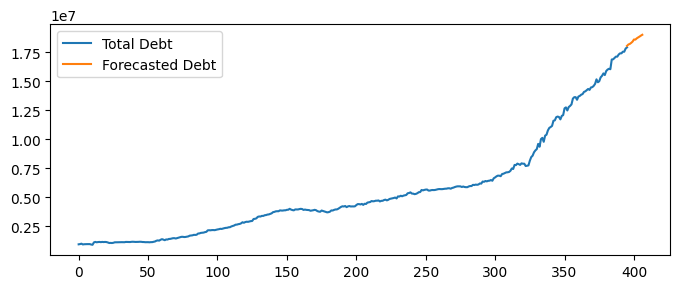

In [13]:
fig, ax = plt.subplots(figsize=(8, 3))
y.plot(ax=ax, label='Total Debt')
pred_level.plot(ax=ax, label='Forecasted Debt')
ax.legend(loc='upper left');

In [11]:
",".join(list(pred_level.astype(int).astype(str)))

'18062714,18184528,18233328,18322609,18433391,18614850,18602110,18711164,18789924,18863629,18946731,19020877'